# Premier League Top 6 Predictor

This notebook trains a machine learning model to predict whether a team finishes in the top 6 based on historical data from 2015–2024.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("processed/league_table.csv")
df.head()

,season,team,rank,points,goals_for,goals_against,wins,draws,losses,goal_diff
0,2015,Leicester,1,81,68,36,23,12,3,32
1,2015,Arsenal,2,71,65,36,20,11,7,29
2,2015,Tottenham,3,70,69,35,19,13,6,34
3,2015,Manchester City,4,66,71,41,19,9,10,30
4,2015,Manchester United,5,66,49,35,19,9,10,14


In [4]:
print(df.shape)
print(df.columns)
df.describe()

(200, 10)
Index(['season', 'team', 'rank', 'points', 'goals_for', 'goals_against',
       'wins', 'draws', 'losses', 'goal_diff'],
      dtype='object')


,season,rank,points,goals_for,goals_against,wins,draws,losses,goal_diff
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000
mean,2019.500000,10.500000,52.510000,53.770000,53.770000,14.570000,8.860000,14.570000,0.00000
std,2.879489,5.780751,18.330026,17.679648,13.997383,6.325755,2.867317,6.080292,28.66581
min,2015.000000,1.000000,12.000000,20.000000,22.000000,2.000000,2.000000,1.000000,-69.00000
25%,2017.000000,5.750000,40.000000,40.000000,44.000000,11.000000,7.000000,10.000000,-19.25000
50%,2019.500000,10.500000,49.000000,51.000000,54.000000,13.000000,9.000000,15.000000,-4.50000
75%,2022.000000,15.250000,66.000000,65.250000,63.000000,19.000000,11.000000,19.000000,18.00000
max,2024.000000,20.000000,100.000000,106.000000,104.000000,32.000000,15.000000,30.000000,79.00000


In [5]:
df["goal_diff"] = df["goals_for"] - df["goals_against"]
df["top_6"] = df["rank"].apply(lambda x: 1 if x <= 6 else 0)
df.head()

,season,team,rank,points,goals_for,goals_against,wins,draws,losses,goal_diff,top_6
0,2015,Leicester,1,81,68,36,23,12,3,32,1
1,2015,Arsenal,2,71,65,36,20,11,7,29,1
2,2015,Tottenham,3,70,69,35,19,13,6,34,1
3,2015,Manchester City,4,66,71,41,19,9,10,30,1
4,2015,Manchester United,5,66,49,35,19,9,10,14,1


Text(0.5, 1.0, 'Points Comparison: Top 6 vs Others')

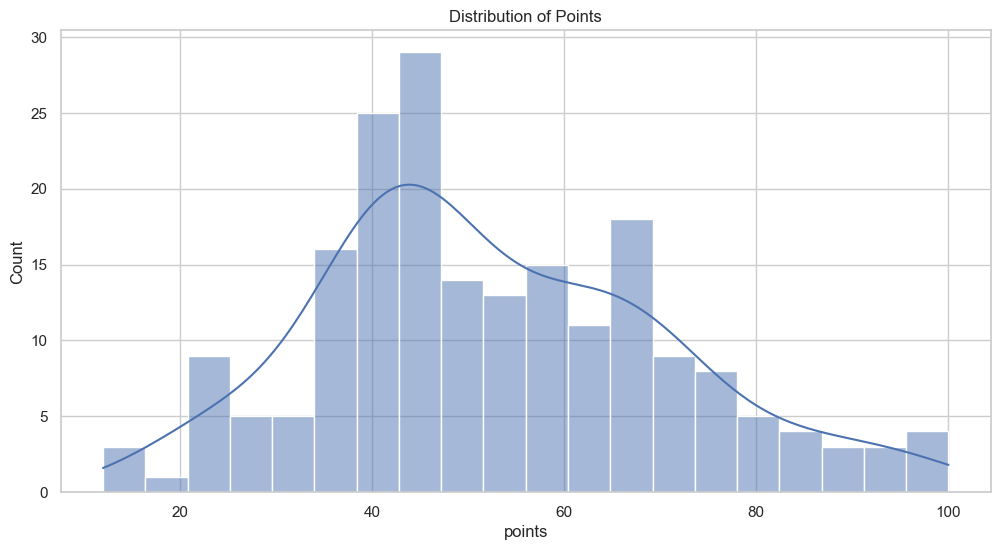

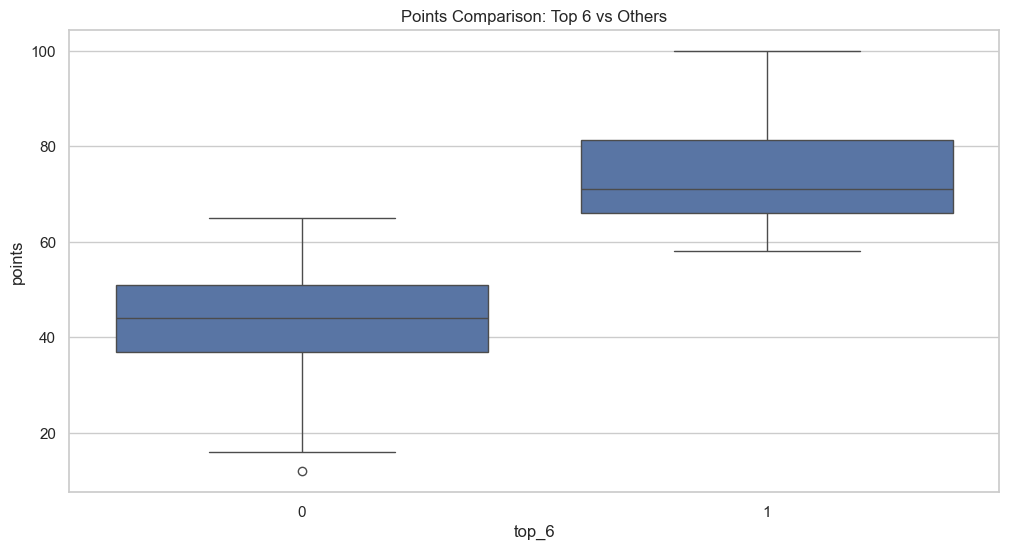

In [6]:
plt.figure(figsize=(12, 6))
sns.histplot(df["points"], bins=20, kde=True)
plt.title("Distribution of Points")

plt.figure(figsize=(12, 6))
sns.boxplot(x="top_6", y="points", data=df)
plt.title("Points Comparison: Top 6 vs Others")

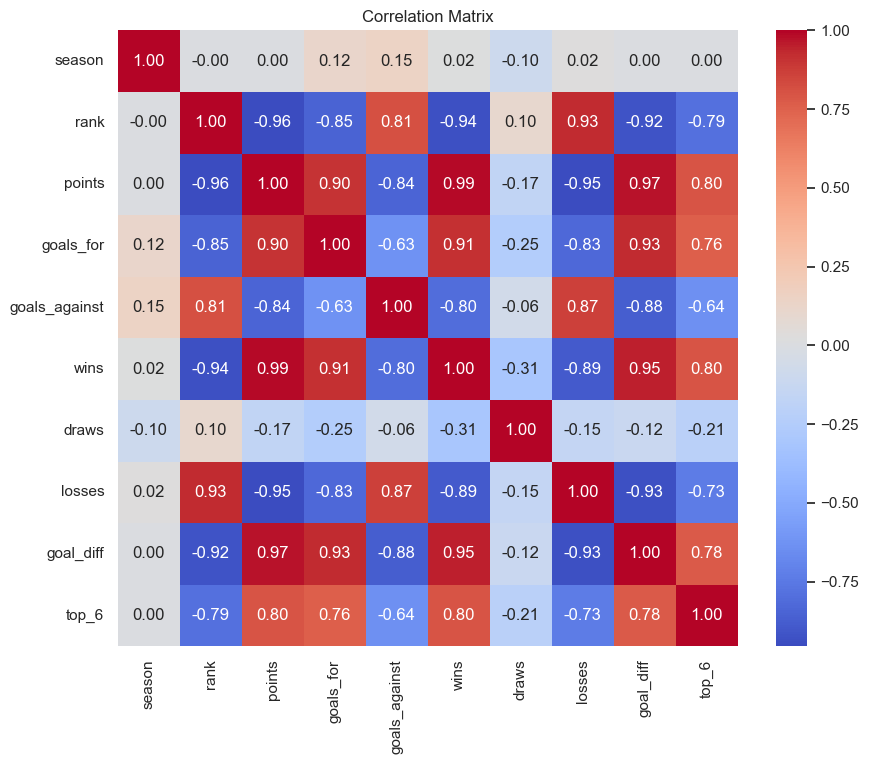

In [7]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])  # Keep only numeric columns
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [10]:
from sklearn.model_selection import train_test_split

features = ["points", "goal_diff", "goals_for", "goals_against", "wins", "draws", "losses"]
X = df[features]
y = df["top_6"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


              precision    recall  f1-score   support

           0       0.93      0.97      0.95        29
           1       0.90      0.82      0.86        11

    accuracy                           0.93        40
   macro avg       0.92      0.89      0.90        40
weighted avg       0.92      0.93      0.92        40



<Axes: >

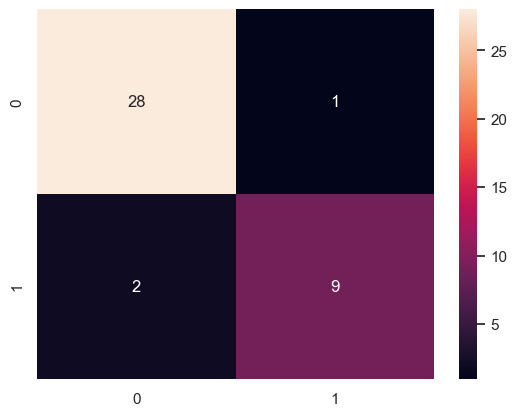

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")

In [16]:
# Predict top 6 for 2024 season as proxy for 2025–2026 prediction
latest_season = df[df["season"] == 2024].copy()
latest_features = latest_season[features]

# Predict probabilities
latest_season["top_6_prob"] = model.predict_proba(latest_features)[:, 1]
latest_season["top_6_pred"] = model.predict(latest_features)

# Sort by predicted probability
latest_season_sorted = latest_season.sort_values("top_6_prob", ascending=False)

# Show top 6 teams predicted for next season
top6_predicted = latest_season_sorted[["team", "points", "top_6_prob", "top_6_pred"]].head(6)
print("Predicted Top 6 Teams for 2025–2026 Season (based on 2024 data):")
print(top6_predicted.to_string(index=False))


Predicted Top 6 Teams for 2025–2026 Season (based on 2024 data):
           team  points  top_6_prob  top_6_pred
      Liverpool      84        1.00           1
Manchester City      71        1.00           1
        Chelsea      69        1.00           1
        Arsenal      74        1.00           1
      Newcastle      66        0.96           1
    Aston Villa      66        0.89           1


In [17]:
top6_predicted.to_csv("processed/predicted_top6_2025.csv", index=False)


In [20]:
import os

# Ensure the directory exists
os.makedirs("processed", exist_ok=True)

import joblib
joblib.dump(model, "processed/top6_model.pkl")


['processed/top6_model.pkl']